In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

In [60]:

BASE_DIR = r'C:\Users\Kohov\OneDrive\Desktop\IDE\ITOG_PROJECT_DATA_SIENCE\data'
EVENTS_PATH = os.path.join(BASE_DIR, 'events.csv')
CATEGORY_PATH = os.path.join(BASE_DIR, 'category_tree.csv')
PROPS1_PATH = os.path.join(BASE_DIR, 'item_properties_part1.csv')
PROPS2_PATH = os.path.join(BASE_DIR, 'item_properties_part2.csv')

CHUNK_SIZE = 100000  # для памяти
SAMPLE_FRAC = 0.9   # для визуализации если не выдержит ноут 

In [61]:
def count_rows(filename):
    """Подсчёт количества строк в CSV"""
    with open(filename, 'r', encoding='utf-8') as f:
        return sum(1 for _ in f) - 1

def load_sample(filename, cols=None, frac=SAMPLE_FRAC, nrows=None):
    """Загружает случайную выборку для EDA"""
    if nrows:
        return pd.read_csv(filename, usecols=cols, nrows=nrows)
    # Если файл огромен, берём случайные строки через skiprows (упрощённо)
    # Для простоты возьмём первые 500k записей
    return pd.read_csv(filename, usecols=cols, nrows=500000)

#### Разведочный анализ данных (EDA)

Общая информация о датасете событий

In [62]:
# Количество записей
n_events = count_rows(EVENTS_PATH)
print(f'Количество записей в events.csv: {n_events}')

# 2. Загружаю  выборку для анализа
events_sample = load_sample(EVENTS_PATH, cols=['timestamp', 'visitorid', 'event', 'itemid'])
print('Размер выборки:', len(events_sample))
print('Типы событий (задание 2.2):', events_sample['event'].unique())

Количество записей в events.csv: 2756101
Размер выборки: 500000
Типы событий (задание 2.2): <ArrowStringArray>
['view', 'addtocart', 'transaction']
Length: 3, dtype: str


Распределение типов событий


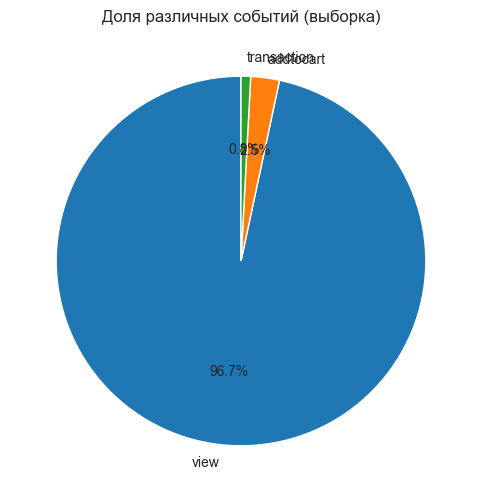

In [63]:
event_counts = events_sample['event'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(event_counts, labels=event_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Доля различных событий (выборка)')
plt.show()

Временной ряд активности

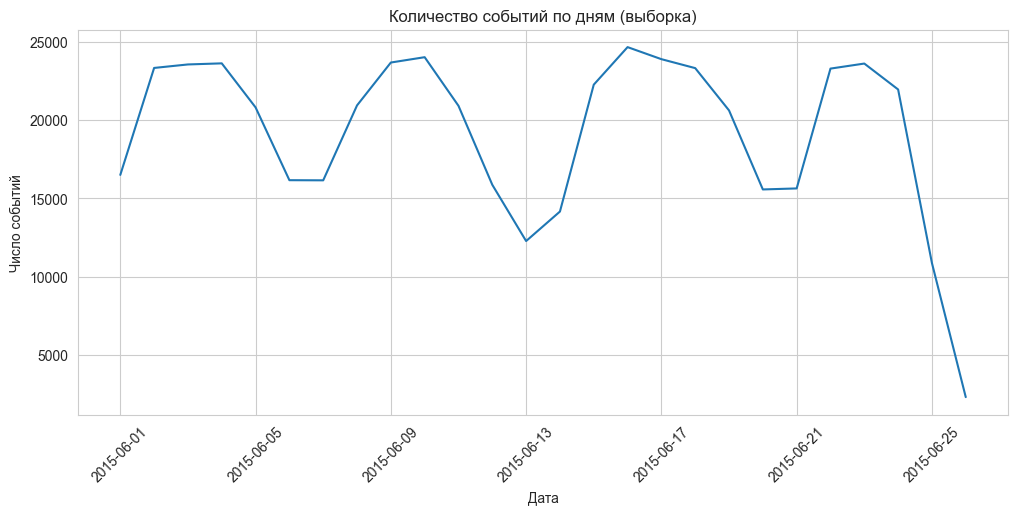

In [64]:
# Преобразуем timestamp в datetime (в миллисекундах)
events_sample['datetime'] = pd.to_datetime(events_sample['timestamp'], unit='ms')
events_sample['date'] = events_sample['datetime'].dt.date
daily_events = events_sample.groupby('date').size()

plt.figure(figsize=(12,5))
daily_events.plot()
plt.title('Количество событий по дням (выборка)')
plt.xlabel('Дата')
plt.ylabel('Число событий')
plt.xticks(rotation=45)
plt.show()

Активность пользователей

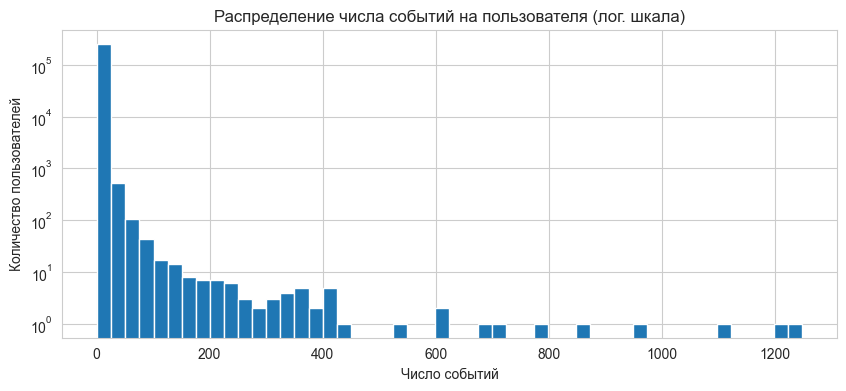

In [65]:
user_activity = events_sample.groupby('visitorid').size()
plt.figure(figsize=(10,4))
plt.hist(user_activity, bins=50, log=True)
plt.title('Распределение числа событий на пользователя (лог. шкала)')
plt.xlabel('Число событий')
plt.ylabel('Количество пользователей')
plt.show()

Топ-20 товаров по просмотрам

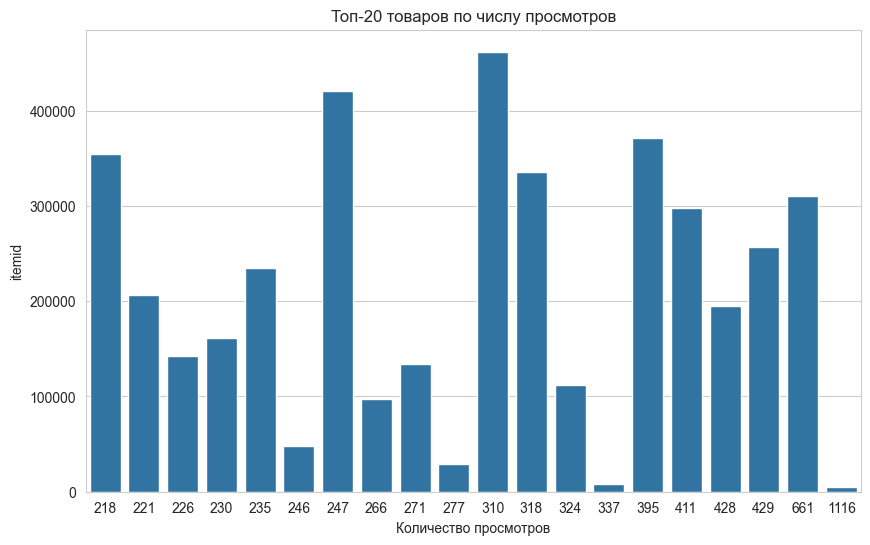

In [66]:
top_views = events_sample[events_sample['event']=='view']['itemid'].value_counts().head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_views.values, y=top_views.index)
plt.title('Топ-20 товаров по числу просмотров')
plt.xlabel('Количество просмотров')
plt.show()

Анализ свойств товаров

In [67]:
# Загружаем выборку из свойств
props_sample = pd.read_csv(PROPS1_PATH, nrows=200000)
unique_props = set(props_sample['property'].unique())

# Добавляем второй файл (если есть)
if os.path.exists(PROPS2_PATH):
    props2_sample = pd.read_csv(PROPS2_PATH, nrows=200000)
    unique_props.update(props2_sample['property'].unique())

print(f'Количество уникальных свойств: {len(unique_props)}')

Количество уникальных свойств: 976


Частота свойств (топ-20)

Топ-20 свойств:
property
888           29622
790           17784
available     14787
categoryid     7737
6              6285
283            5911
776            5715
678            4679
364            4600
202            4459
764            4161
917            4125
839            4097
159            4037
112            4007
227            3303
698            2892
451            2531
663            2432
962            2351
Name: count, dtype: int64


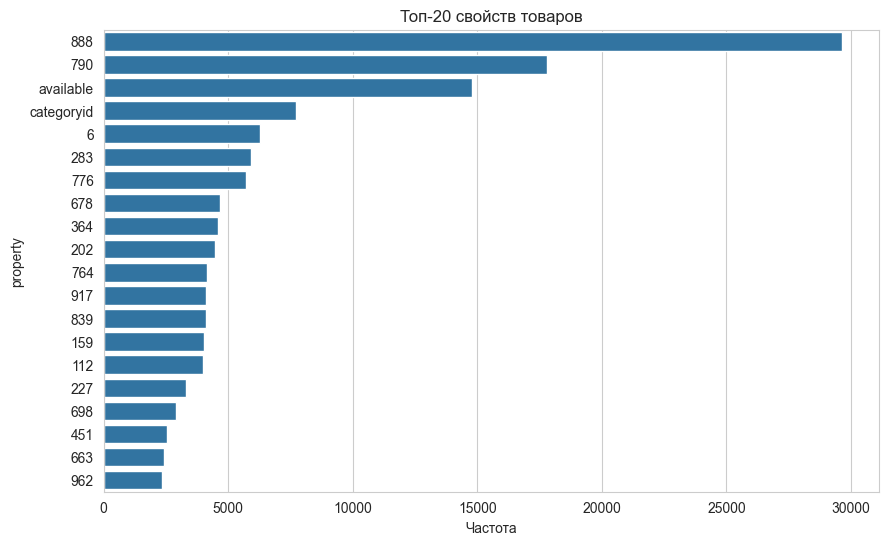

In [68]:
# Собираем частоты свойств на всей выборке
prop_counts = props_sample['property'].value_counts()
top_props = prop_counts.head(20)
print('Топ-20 свойств:')
print(top_props)

# Визуализация
plt.figure(figsize=(10,6))
sns.barplot(x=top_props.values, y=top_props.index)
plt.title('Топ-20 свойств товаров')
plt.xlabel('Частота')
plt.show()

#### Построение валидационного датасета (временное разбиение)

Создание train/val/test по временным меткам

In [69]:
# Определяем границы 

# Использую данные до 25 июня как train, 26–30 июня как val, с 1 июля как test
train_end = '2015-06-25'
val_end = '2015-06-30'

train_chunks = []
val_chunks = []
test_chunks = []

for chunk in pd.read_csv(EVENTS_PATH, chunksize=CHUNK_SIZE):
    chunk['datetime'] = pd.to_datetime(chunk['timestamp'], unit='ms', errors='coerce')
    chunk = chunk.dropna(subset=['datetime'])
    
    train = chunk[chunk['datetime'] <= train_end]
    val = chunk[(chunk['datetime'] > train_end) & (chunk['datetime'] <= val_end)]
    test = chunk[chunk['datetime'] > val_end]
    
    if not train.empty:
        train_chunks.append(train)
    if not val.empty:
        val_chunks.append(val)
    if not test.empty:
        test_chunks.append(test)

train_df = pd.concat(train_chunks, ignore_index=True)
val_df = pd.concat(val_chunks, ignore_index=True)
test_df = pd.concat(test_chunks, ignore_index=True)

print(f'Размеры: train = {len(train_df)}, val = {len(val_df)}, test = {len(test_df)}')

Размеры: train = 1083795, val = 95802, test = 1576504


Проверка отсутствия утечек

In [70]:
print('Train период:', train_df['datetime'].min(), '–', train_df['datetime'].max())
print('Val период:', val_df['datetime'].min(), '–', val_df['datetime'].max())
print('Test период:', test_df['datetime'].min(), '–', test_df['datetime'].max())

Train период: 2015-05-03 03:00:04.384000 – 2015-06-24 23:59:55.514000
Val период: 2015-06-25 00:00:11.076000 – 2015-06-29 23:59:54.620000
Test период: 2015-06-30 00:00:03.778000 – 2015-09-18 02:59:47.788000


####  Генерация простых факторов (пример)

Популярность товаров и средняя цена (если есть)

In [71]:
# Рассчитываем популярность товаров по числу просмотров в train
item_popularity = train_df[train_df['event']=='view']['itemid'].value_counts()
# Для демонстрации  DataFrame с факторами
item_features = pd.DataFrame({'itemid': item_popularity.index, 'popularity': item_popularity.values})
print('Пример факторов для товаров:')
print(item_features.head())

Пример факторов для товаров:
   itemid  popularity
0    5411        1209
1  309778        1101
2  370653        1081
3  369447         996
4  298009         983


In [72]:
#Для рассчета Recall 
def recall_at_k(recommended, actual, k=3):
    if not actual:
        return 0
    hits = set(recommended[:k]) & set(actual)
    return len(hits) / len(actual)

#### Оценка топ-популярных товаров на тесте

In [73]:
# Топ-3 самых популярных товара в train
top3_train = train_df[train_df['event']=='view']['itemid'].value_counts().head(3).index.tolist()
print('Топ-3 популярных товара по просмотрам в train:', top3_train)

# Для каждого пользователя в тесте рекомендуем эти 3 товара (одинаковые для всех)
# Найдём транзакции в тесте
test_trans = test_df[test_df['event']=='transaction']

# Группируем по пользователю, берём уникальные купленные товары
user_actual = test_trans.groupby('visitorid')['itemid'].apply(list).to_dict()

# Считаем Recall@3
total_recall = 0
n_users = len(user_actual)
for user, items in user_actual.items():
    total_recall += recall_at_k(top3_train, items, k=3)

recall = total_recall / n_users if n_users > 0 else 0
print(f'Recall@3 для топ-3 популярных товаров: {recall:.4f}')

Топ-3 популярных товара по просмотрам в train: [5411, 309778, 370653]
Recall@3 для топ-3 популярных товаров: 0.0003


#### Дополнительные исследования 

In [74]:
print(f' Количество записей событий: {n_events}')

 Количество записей событий: 2756101


In [75]:
# Все типы из полного датасета (проход по чанкам)
event_types_full = set()
for chunk in pd.read_csv(EVENTS_PATH, usecols=['event'], chunksize=CHUNK_SIZE):
    event_types_full.update(chunk['event'].unique())
print('Типы событий в полном датасете:', sorted(event_types_full))
expected = {'view', 'addtocart', 'transaction', 'checkout', 'review'}
present = expected.intersection(event_types_full)
print('   Присутствуют из перечисленных:', sorted(present))

Типы событий в полном датасете: ['addtocart', 'transaction', 'view']
   Присутствуют из перечисленных: ['addtocart', 'transaction', 'view']


In [76]:
unique_props_full = set()
for file in [PROPS1_PATH, PROPS2_PATH]:
    for chunk in pd.read_csv(file, usecols=['property'], chunksize=CHUNK_SIZE):
        unique_props_full.update(chunk['property'].unique())

print(f'Количество уникальных свойств товаров: {len(unique_props_full)}')

Количество уникальных свойств товаров: 1104


In [77]:
# Первый проход – топ-3 по транзакциям до 1 июля
counter_before = Counter()
for chunk in pd.read_csv(EVENTS_PATH, chunksize=CHUNK_SIZE):
    chunk['datetime'] = pd.to_datetime(chunk['timestamp'], unit='ms', errors='coerce')
    mask = (chunk['event'] == 'transaction') & (chunk['datetime'] <= '2015-07-01')
    for item in chunk.loc[mask, 'itemid']:
        counter_before[item] += 1

top3_items = [item for item, _ in counter_before.most_common(3)]

# Второй проход – доля этих товаров в транзакциях после 1 июля
total_after = 0
top3_after = 0
for chunk in pd.read_csv(EVENTS_PATH, chunksize=CHUNK_SIZE):
    chunk['datetime'] = pd.to_datetime(chunk['timestamp'], unit='ms', errors='coerce')
    mask_after = (chunk['event'] == 'transaction') & (chunk['datetime'] > '2015-07-01')
    trans_after = chunk.loc[mask_after]
    total_after += len(trans_after)
    top3_after += trans_after['itemid'].isin(top3_items).sum()

if total_after > 0:
    cover = top3_after / total_after * 100
    print(f'Процент продаж топ-3 товаров: {cover:.2f}%')
    
else:
    print('Нет транзакций после 1 июля')

Процент продаж топ-3 товаров: 0.60%
